In [1]:
from turan_env_c import CEnv, CHECKER_C3,CHECKER_C4,CHECKER_C3C4,CHECKER_K23,CHECKER_THETA123,CHECKER_BULL, CHECKER_BOWTIE, CHECKER_K4
import numpy as np 
import networkx as nx
import matplotlib.pyplot as plt
from checkers import (
  C3Checker, C4Checker, C3C4Checker,
  K23Checker, Theta123Checker, BullChecker, BowTieChecker, K4Checker
)

In [2]:
def draw_adj(adj, ax=None, title=None):
    n = len(adj)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for u in range(n):
        for v in range(u+1, n):
            if adj[u, v]:
                G.add_edge(u, v)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True,
            node_color='#1D9E75', node_size=500,
            font_color='white', font_weight='bold',
            edge_color='#444', width=1.5)
    if title:
        ax.set_title(title, fontsize=10)
    return ax

In [3]:
e = CEnv(100, 1024, checker_id=CHECKER_K23)

In [4]:
e.benchmark()

500 steps x 1024 envs in 0.15s
  3,388,636 steps/sec
  3.39M steps/sec


In [5]:
# import pandas as pd

# results = []

# for checker_id, checker_name in [
#     (CHECKER_C3,       'C3'),
#     (CHECKER_C4,       'C4'),
#     (CHECKER_C3C4,     'C3C4'),
#     (CHECKER_K23,      'K23'),
#     (CHECKER_THETA123, 'Theta123'),
#     (CHECKER_BULL,     'Bull'),
#     (CHECKER_BOWTIE,   'BowTie'),
# ]:
#     for n in [20, 50, 100]:
#         for num_envs in [256, 512, 1024, 2048, 4096, 8192]:
#             import time
#             e = CEnv(n, num_envs, checker_id=checker_id)
#             e.reset()
#             # warmup
#             for _ in range(20):
#                 actions = np.random.randint(0, e.num_actions, num_envs, dtype=np.int32)
#                 e.step(actions)
#             # measure
#             t0 = time.time()
#             for _ in range(200):
#                 actions = np.random.randint(0, e.num_actions, num_envs, dtype=np.int32)
#                 e.step(actions)
#             dt = time.time() - t0
#             sps = 200 * num_envs / dt
#             e.close()
#             results.append(dict(
#                 checker=checker_name,
#                 n=n,
#                 num_envs=num_envs,
#                 sps=sps,
#                 Msps=sps/1e6,
#             ))
#             print(f'{checker_name:10s} n={n:3d} envs={num_envs:5d} -> {sps/1e6:.2f}M steps/sec')

# df = pd.DataFrame(results)

# # best num_envs per (checker, n)
# print('\n=== optimal num_envs per config ===')
# idx = df.groupby(['checker','n'])['sps'].idxmax()
# print(df.loc[idx][['checker','n','num_envs','Msps']].to_string(index=False))

In [6]:
def make_forbidden_graphs():
  bowtie = nx.Graph()
  bowtie.add_edges_from([(0,1),(1,2),(0,2),(2,3),(3,4),(2,4)])

  theta = nx.Graph()
  theta.add_edges_from([(0,1),(0,2),(2,1),(0,3),(3,4),(4,1)])

  return {
    'C3':     nx.cycle_graph(3),
    'C4':     nx.cycle_graph(4),
    'K23':    nx.complete_bipartite_graph(2, 3),
    'Bull':   nx.bull_graph(),
    'BowTie': bowtie,
    'Theta123': theta,
  }

FORBIDDEN = make_forbidden_graphs()

def brute_force(adj, name):
  H = FORBIDDEN[name]
  n = len(adj)
  h_nodes = list(H.nodes())
  h_edges = list(H.edges())
  k = len(h_nodes)
  from itertools import permutations
  for perm in permutations(range(n), k):
    mapping = {h_nodes[i]: perm[i] for i in range(k)}
    if all(adj[mapping[u]][mapping[v]] for u, v in h_edges):
      return True
  return False

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
0.0
[False]


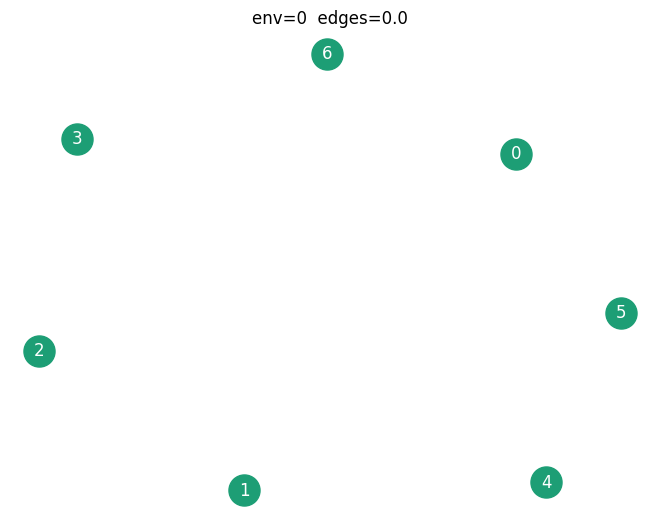

adding edge: (0, 1)
[[0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


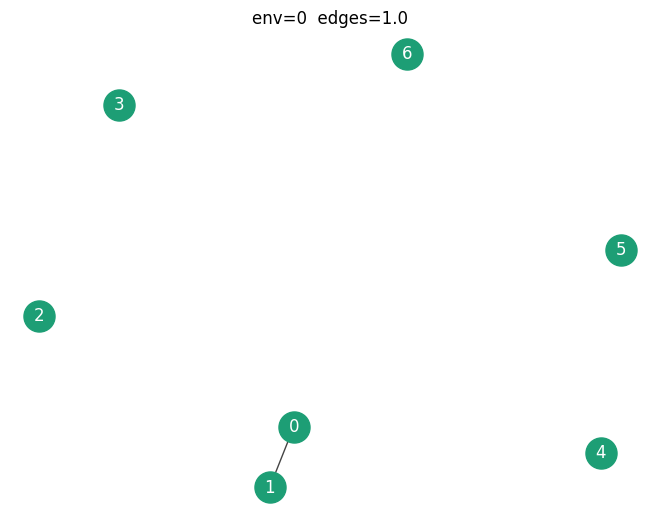

adding edge: (0, 2)
[[0 1 1 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


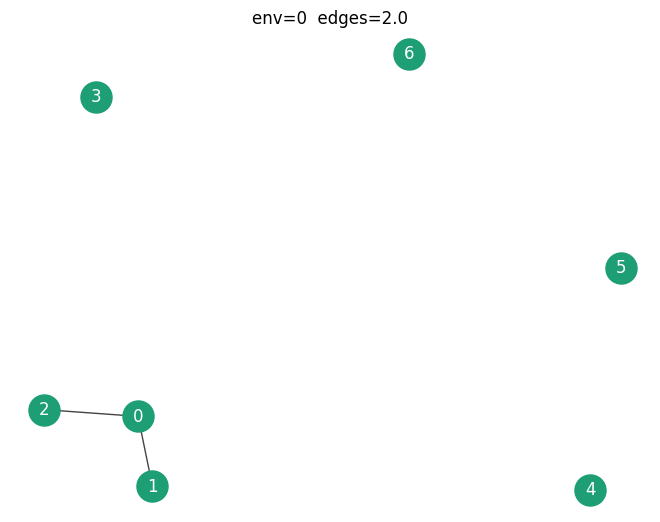

adding edge: (0, 3)
[[0 1 1 1 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


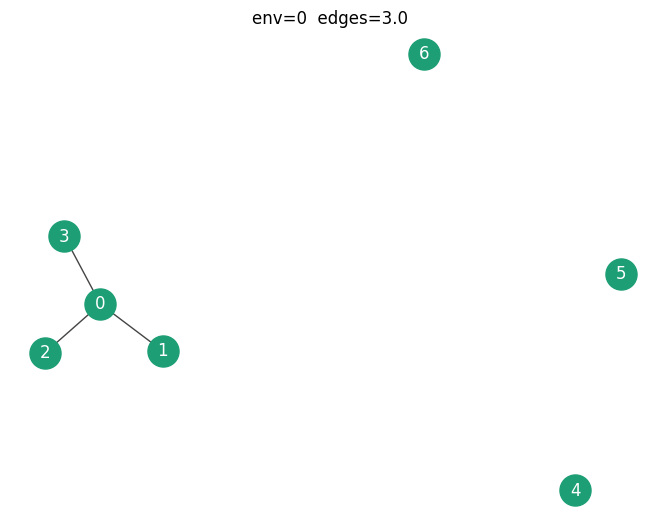

adding edge: (0, 4)
[[0 1 1 1 1 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


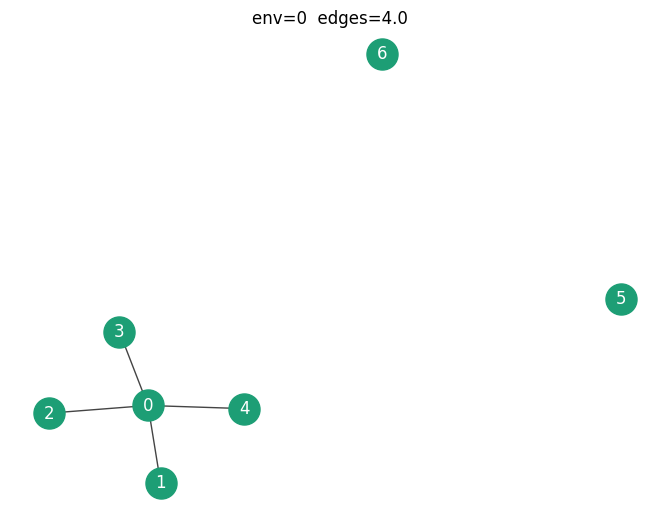

adding edge: (0, 5)
[[0 1 1 1 1 1 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


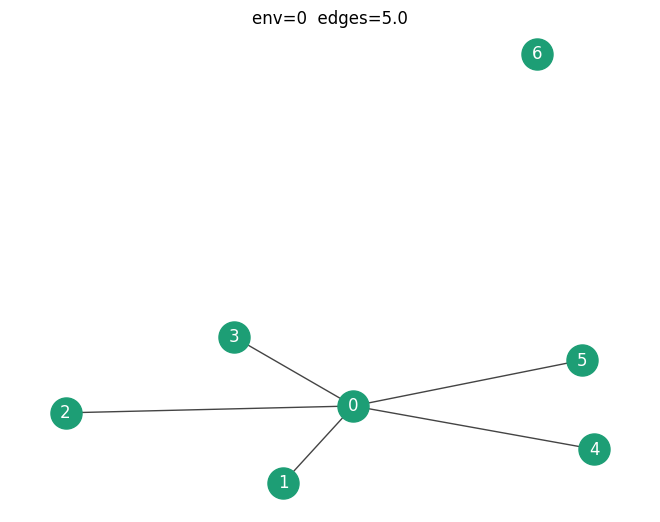

adding edge: (0, 6)
[[0 1 1 1 1 1 1]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]]
[-0.01]
[False]


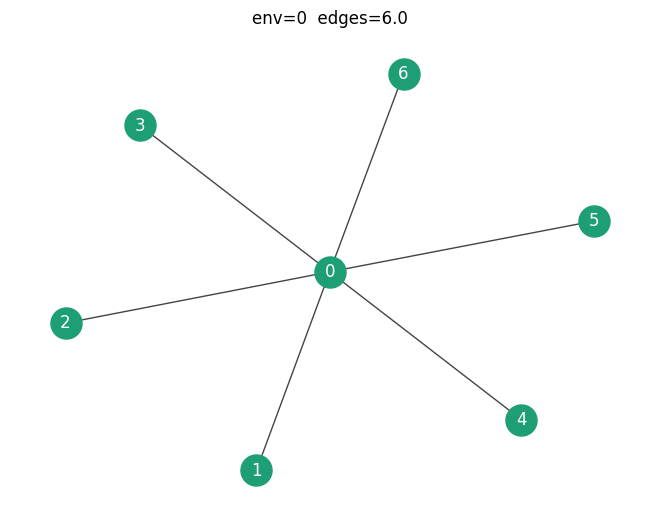

adding edge: (1, 2)
[[0 1 1 1 1 1 1]
 [1 0 1 0 0 0 0]
 [1 1 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]]
[-0.01]
[False]


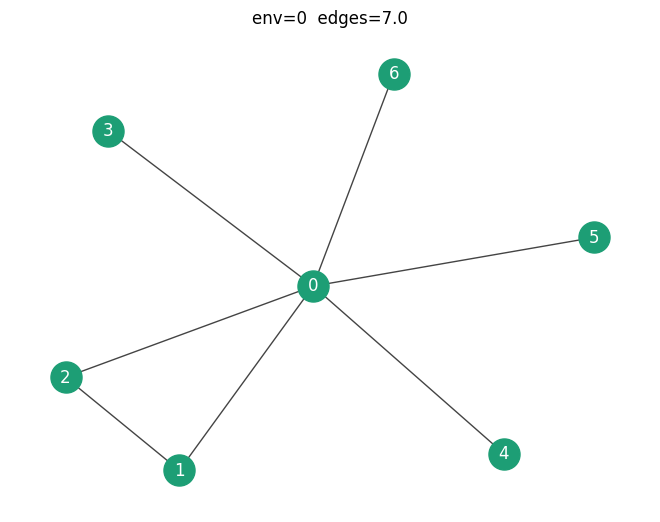

adding edge: (1, 3)
[[0 1 1 1 1 1 1]
 [1 0 1 1 0 0 0]
 [1 1 0 0 0 0 0]
 [1 1 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]]
[-0.01]
[False]


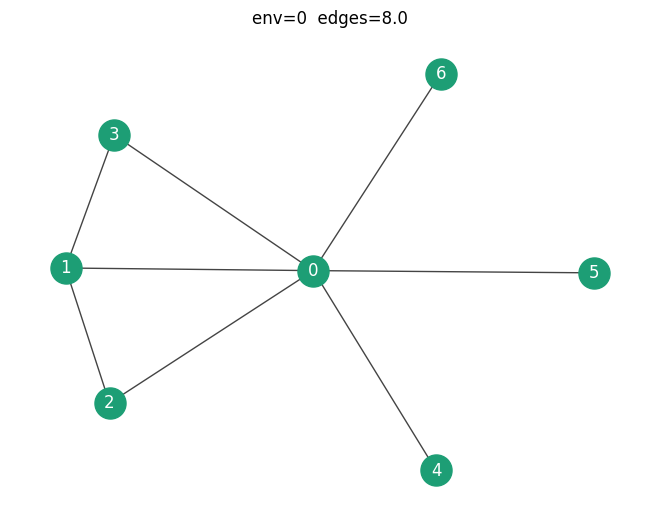

adding edge: (1, 4)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[0.]
[ True]


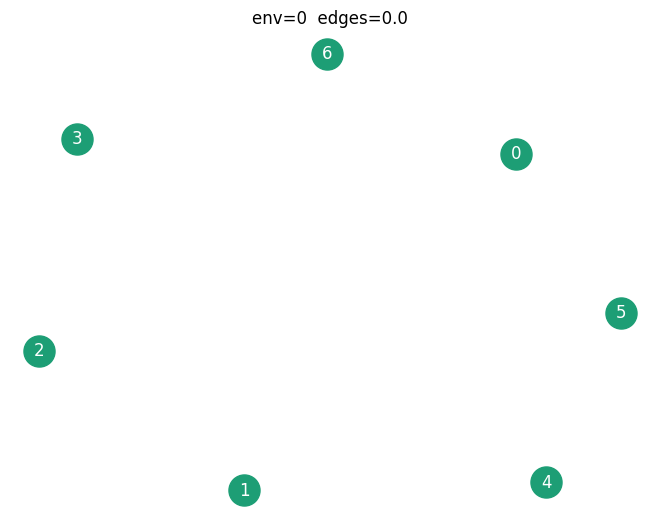

adding edge: (1, 5)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


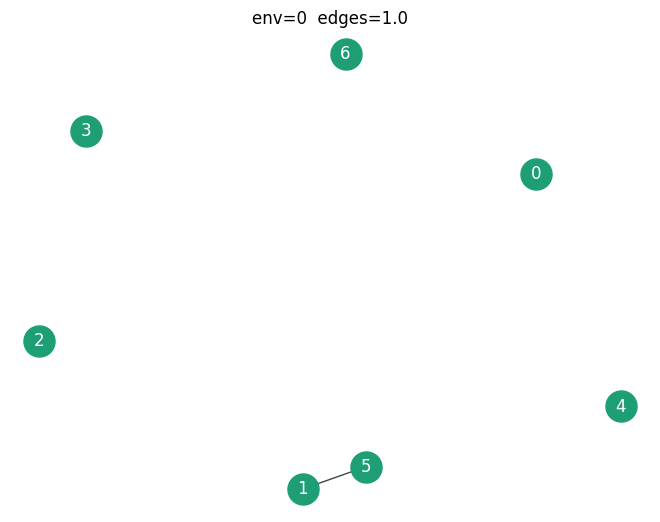

adding edge: (1, 6)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]]
[-0.01]
[False]


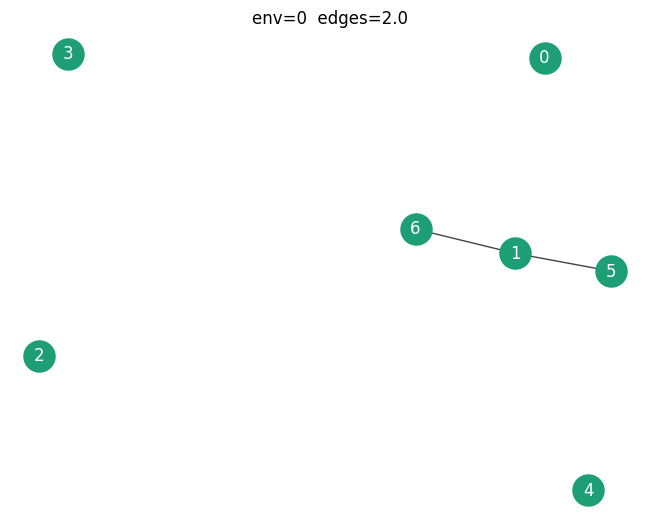

adding edge: (2, 3)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]]
[-0.01]
[False]


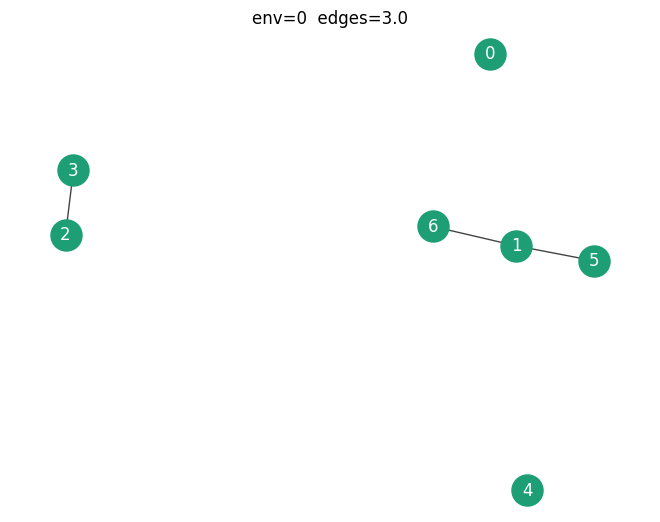

adding edge: (2, 4)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 1 1 0 0]
 [0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]]
[-0.01]
[False]


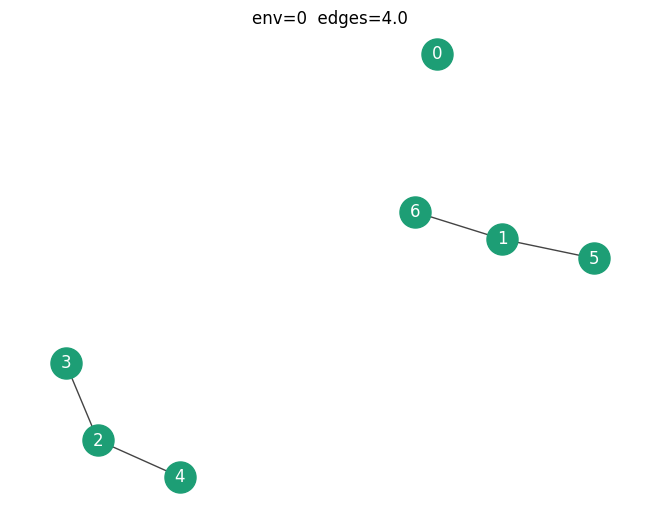

adding edge: (2, 5)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 1 1 1 0]
 [0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 1 1 0 0 0 0]
 [0 1 0 0 0 0 0]]
[-0.01]
[False]


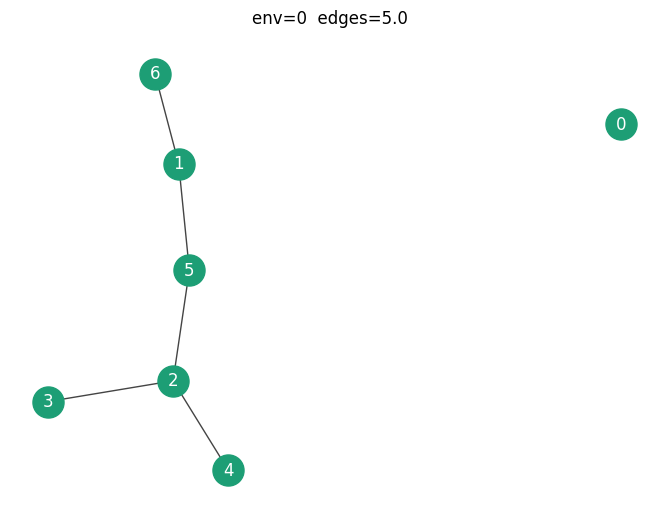

adding edge: (2, 6)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 1 1 1 1]
 [0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 1 1 0 0 0 0]
 [0 1 1 0 0 0 0]]
[-0.01]
[False]


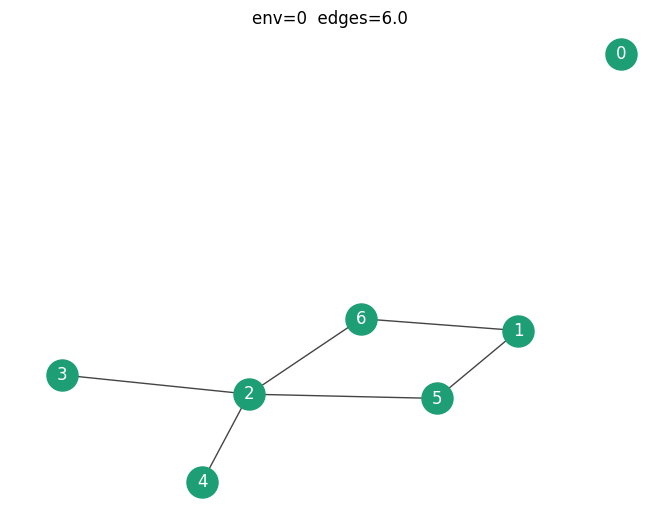

adding edge: (3, 4)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 1 1 1 1]
 [0 0 1 0 1 0 0]
 [0 0 1 1 0 0 0]
 [0 1 1 0 0 0 0]
 [0 1 1 0 0 0 0]]
[-0.01]
[False]


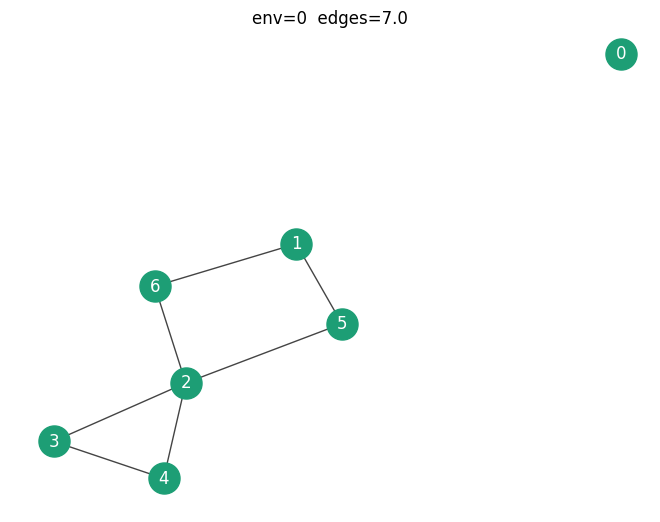

adding edge: (3, 5)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 1 1 1 1]
 [0 0 1 0 1 1 0]
 [0 0 1 1 0 0 0]
 [0 1 1 1 0 0 0]
 [0 1 1 0 0 0 0]]
[-0.01]
[False]


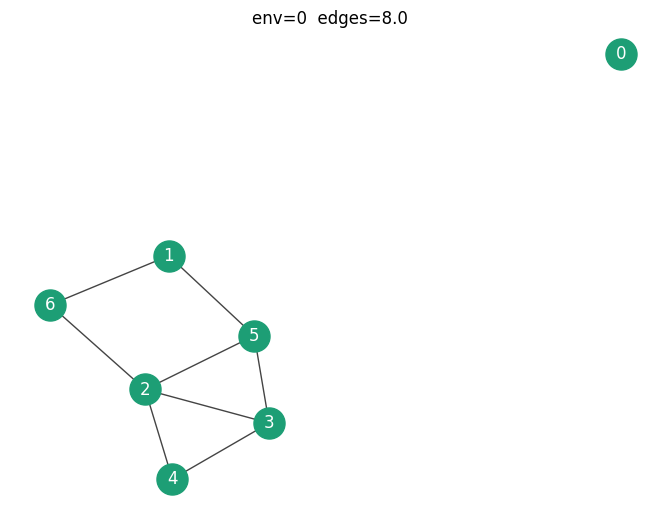

adding edge: (3, 6)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
[0.]
[ True]


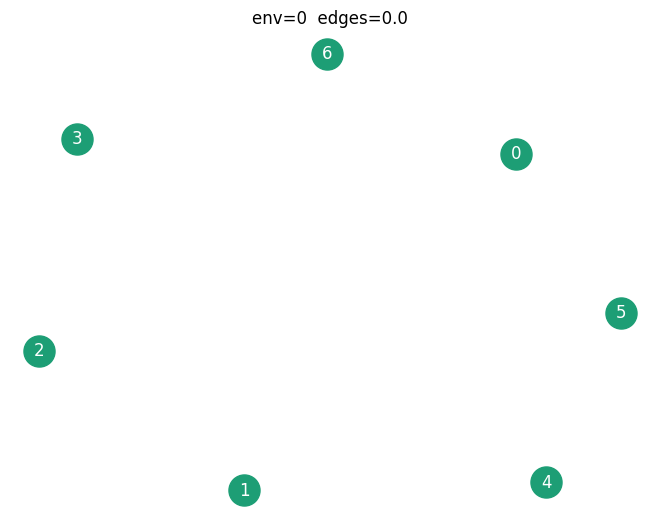

adding edge: (4, 5)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0]]
[-0.01]
[False]


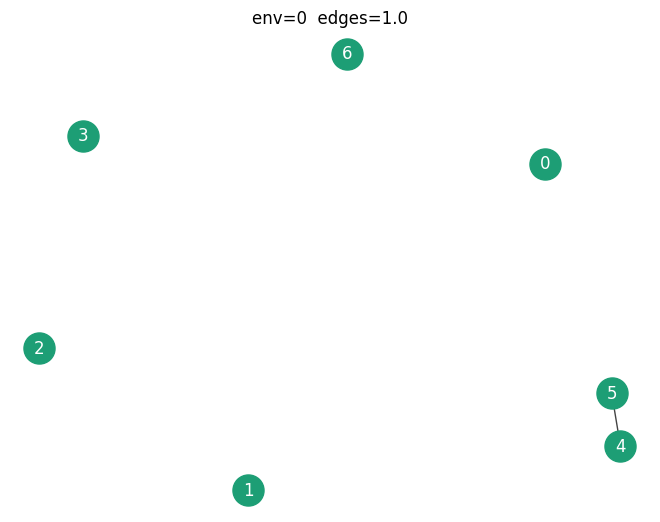

adding edge: (4, 6)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0]]
[-0.01]
[False]


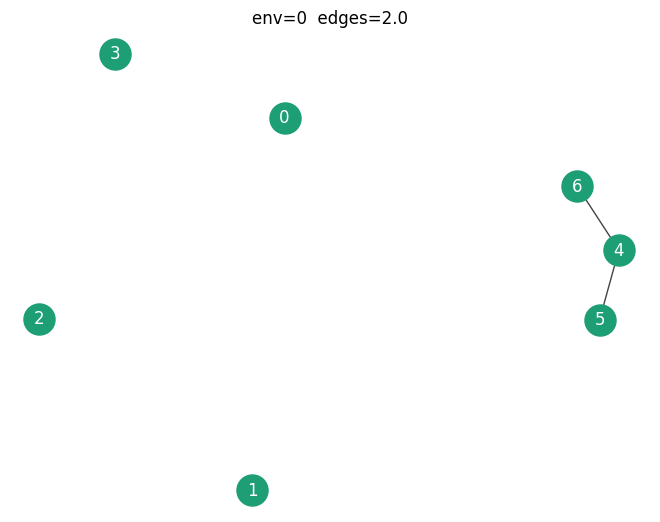

adding edge: (5, 6)


In [7]:
edge_list = [i for i in range(7*3)]
env = CEnv(7,1,checker_id =CHECKER_K23)
obs,rew,done = env.reset()
prev_obs = np.zeros_like(obs).astype(obs.dtype)
print(obs.reshape(7,7))
done = np.array([0]).astype(bool)
rew = 0.0
for e in edge_list: 
  u = env._edge_u[e] 
  v = env._edge_v[e]
  print(obs.reshape(7,7))
  print(rew)
  print(done)
  env.draw_obs()
  obs,rew,done = env.step(np.array([e]))
  

  print(f"adding edge: {(u,v)}")
  

In [8]:
def stress_test_c_env(checker_id, checker_py, name, n=12, num_envs=1, n_steps=1000):
    env = CEnv(n, num_envs, checker_id=checker_id)
    env.reset()
    fp = fn = 0

    for step in range(n_steps):
        actions  = np.random.randint(0, env.num_actions, num_envs, dtype=np.int32)
        was_done = env.done.copy().astype(bool)
        
        # run python checker BEFORE step
        py_results = []
        for e in range(num_envs):
            u = env._edge_u[actions[e]]
            v = env._edge_v[actions[e]]
            adj = env.obs[e].reshape(n, n)
            py_results.append(checker_py.check(adj, u, v))
        
        obs, reward, done = env.step(actions)
        
        for e in range(num_envs):
            if was_done[e]: continue
            if done[e] and not py_results[e]:
                fp += 1
                print(f'FP step={step} env={e}')
            if py_results[e] and not done[e]:
                fn += 1
                print(f'FN step={step} env={e}')

    print(f'{name:10s}  fp={fp}  fn={fn}  {"PASS" if fp==0 and fn==0 else "FAIL"}')
    env.close()

# run all
n = 12
stress_test_c_env(CHECKER_C3,       C3Checker(n),       'C3',       n=n)
stress_test_c_env(CHECKER_C4,       C4Checker(n),       'C4',       n=n)
stress_test_c_env(CHECKER_C3C4,     C3C4Checker(n),     'C3C4',     n=n)
stress_test_c_env(CHECKER_K23,      K23Checker(n),      'K23',      n=n)
stress_test_c_env(CHECKER_THETA123, Theta123Checker(n), 'Theta123', n=n)
stress_test_c_env(CHECKER_BULL,     BullChecker(n),     'Bull',     n=n)
stress_test_c_env(CHECKER_BOWTIE,   BowTieChecker(n),   'BowTie',   n=n)
stress_test_c_env(CHECKER_K4,       K4Checker(n),        'K4',      n=n)

C3          fp=0  fn=0  PASS
C4          fp=0  fn=0  PASS
C3C4        fp=0  fn=0  PASS


K23         fp=0  fn=0  PASS
Theta123    fp=0  fn=0  PASS
Bull        fp=0  fn=0  PASS
BowTie      fp=0  fn=0  PASS
K4          fp=0  fn=0  PASS


In [9]:
env = CEnv(12, 1, checker_id=CHECKER_K4)
env.reset()
# manually step edge (0,1)
obs, rew, done = env.step(np.array([0], dtype=np.int32))
print(f'done after first edge: {done}')  # should be False

done after first edge: [False]
